# Ejercicio 5. Incorporación de datos adicionales

El sistema pasa de trabajar con 2026 a trabajar con 2024 y 2026. Los archivos de 2024 se descargan de la misma fuente de la TLC.

In [1]:
import os
import time
from pathlib import Path

import duckdb
import pandas as pd

if Path.cwd().name == "notebooks":
    os.chdir("..")

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
con = duckdb.connect()


def consulta(ruta):
    """Imprime un archivo de sql, lo ejecuta y muestra el tiempo"""
    texto = Path("sql", ruta).read_text(encoding="utf-8")
    print(texto)
    inicio = time.perf_counter()
    resultado = con.execute(texto).df()
    print(f"-- {time.perf_counter() - inicio:.2f} s")
    return resultado

import subprocess
import sys

con.execute(Path("sql/vistas.sql").read_text(encoding="utf-8"))

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

COLOR = {"yellow": "#eda100", "green": "#008300"}
NOMBRE = {"yellow": "Amarillo", "green": "Verde"}
COLOR_ANIO = {2024: "#2a78d6", 2025: "#eb6834", 2026: "#1baf7a"}
MESES = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e", "axes.titlecolor": "#0b0b0b",
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "lines.solid_capstyle": "round", "lines.solid_joinstyle": "round",
    "legend.frameon": False, "legend.fontsize": 9, "figure.dpi": 110, "font.size": 10,
})
miles = FuncFormatter(lambda x, _: f"{x:,.0f}")

## 5.1 Cambio en el sistema de descarga

En scripts/download_data.py la lista ANIOS pasa de (2026,) a (2024, 2026). No hay otro cambio. verificar_descarga.py toma la misma lista, y la URL, la carpeta de destino y la regla de archivos existentes quedan igual.

## 5.2 a 5.4 Nueva descarga

data/raw tenía los 16 archivos de 2026 del ejercicio 2. La salida de la descarga está en docs/evidencias/05_descarga_2024.txt.

| Estado | Archivos | Detalle |
| --- | --- | --- |
| Descargados | 24 | Los 12 meses de 2024 de cada tipo |
| Ya existían | 17 | Los 16 de 2026 y el catálogo de zonas |
| No publicados | 8 | Septiembre a diciembre de 2026 |
| Fallidos | 0 | |

Los archivos de 2026 se conservaron y no se pidieron otra vez al servidor. Una nueva ejecución ya no descarga nada. Las celdas de descarga y verificación pasan --anios 2024 2026, los años de este ejercicio, porque ANIOS incluye 2025 desde el ejercicio 8.

In [2]:
salida = subprocess.run([sys.executable, "scripts/download_data.py", "--anios", "2024", "2026"], capture_output=True, text=True).stdout
print(salida[salida.index("RESUMEN"):])

RESUMEN
  descargados   : 0
  ya existian   : 41
  no publicados : 8
      yellow 2026-09, yellow 2026-10, yellow 2026-11, yellow 2026-12, green 2026-09, green 2026-10, green 2026-11, green 2026-12
  fallidos      : 0



## 5.5 Verificación

La verificación compara data/raw con la lista de la TLC para 2024 y 2026.

In [3]:
salida = subprocess.run([sys.executable, "scripts/verificar_descarga.py", "--anios", "2024", "2026"], capture_output=True, text=True)
print(salida.stdout.splitlines()[-1])

40 de 40 archivos publicados completos. Detalle en docs/verificacion_descarga.csv


DuckDB confirma desde el pie de cada Parquet cuántos archivos, meses y registros hay por tipo y año.

In [4]:
consulta("ej5/01_archivos_por_anio.sql")

-- Archivos, meses y registros por tipo de taxi y año, según el pie de cada Parquet
SELECT
    regexp_extract(file_name, '(yellow|green)_tripdata', 1) AS tipo,
    regexp_extract(file_name, '_(\d{4})-\d{2}\.parquet', 1)::INT AS anio,
    count(*) AS archivos,
    min(regexp_extract(file_name, '(\d{4}-\d{2})\.parquet', 1)) AS primer_mes,
    max(regexp_extract(file_name, '(\d{4}-\d{2})\.parquet', 1)) AS ultimo_mes,
    sum(num_rows)::BIGINT AS registros
FROM parquet_file_metadata('data/raw/*/*/*.parquet')
GROUP BY tipo, anio
ORDER BY tipo DESC, anio

-- 0.01 s


,tipo,anio,archivos,primer_mes,ultimo_mes,registros
0,yellow,2024,12,2024-01,2024-12,41169720
1,yellow,2026,8,2026-01,2026-08,29703355
2,green,2024,12,2024-01,2024-12,660218
3,green,2026,8,2026-01,2026-08,337114


2024 llega completo, con 12 archivos por tipo, 41,169,720 viajes amarillos y 660,218 verdes. Junto con 2026 suman 71,870,407 registros.

## 5.6 Consulta conjunta de 2024 y 2026

Una sola consulta sobre la vista viajes_validos, que lee todos los Parquet de data/raw, entrega los indicadores de cada año.

In [5]:
consulta("ej5/02_viajes_por_anio.sql")

-- Viajes válidos e indicadores por año y tipo de taxi, en una sola consulta sobre todos los años
SELECT
    year(periodo) AS anio,
    taxi,
    count(DISTINCT periodo) AS meses,
    count(*) AS viajes,
    round(count(*) / count(DISTINCT CAST(pickup_datetime AS DATE))) AS viajes_por_dia,
    round(avg(trip_distance), 2) AS distancia_prom,
    round(avg(total_amount), 2) AS total_prom,
    round(100 * avg((coalesce(payment_type, 0) = 0)::INT), 1) AS pct_flex_fare,
    round(100 * avg((cbd_congestion_fee > 0)::INT), 1) AS pct_con_cargo_cbd
FROM viajes_validos
GROUP BY anio, taxi
ORDER BY taxi DESC, anio



-- 0.90 s


,anio,taxi,meses,viajes,viajes_por_dia,distancia_prom,total_prom,pct_flex_fare,pct_con_cargo_cbd
0,2024,yellow,12,39673306,108397.0,3.42,28.63,9.3,0.0
1,2026,yellow,8,28223766,116147.0,3.51,30.24,24.9,72.4
2,2024,green,12,618891,1691.0,2.93,24.06,3.8,0.0
3,2026,green,8,321395,1323.0,3.35,25.36,14.7,8.5


Para comparar meses iguales se agrupa por mes y año.

In [6]:
meses = consulta("ej5/03_meses_por_anio.sql")
meses.pivot_table(index="mes", columns=["taxi", "anio"], values="viajes_por_dia")

-- Viajes por día de cada mes, para comparar el mismo mes en distintos años
SELECT
    taxi,
    month(periodo) AS mes,
    year(periodo) AS anio,
    round(count(*) / day(last_day(periodo))) AS viajes_por_dia
FROM viajes_validos
GROUP BY taxi, periodo
ORDER BY taxi DESC, mes, anio



-- 0.70 s


taxi   green            yellow          
anio    2024    2026      2024      2026
mes                                     
1     1713.0  1244.0   92478.0  113401.0
2     1733.0  1271.0   99959.0  114619.0
3     1739.0  1365.0  110873.0  121346.0
4     1759.0  1405.0  113711.0  122437.0
5     1848.0  1382.0  116606.0  126158.0
6     1716.0  1407.0  114179.0  121515.0
7     1558.0  1264.0   95842.0  107907.0
8     1562.0  1243.0   92403.0  102022.0
9     1701.0     NaN  116040.0       NaN
10    1709.0     NaN  118681.0       NaN
11    1630.0     NaN  116906.0       NaN
12    1626.0     NaN  113422.0       NaN

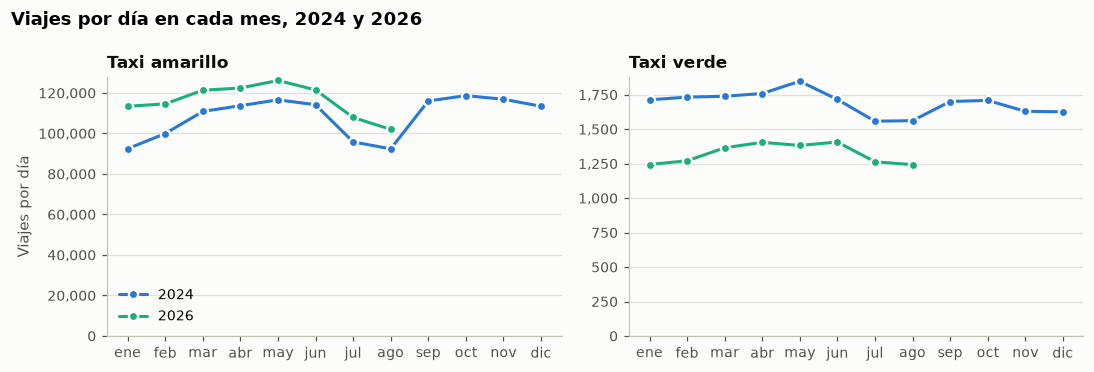

In [7]:
fig, ejes = plt.subplots(1, 2, figsize=(10, 3.4))
for eje, taxi in zip(ejes, ["yellow", "green"]):
    for anio, d in meses[meses.taxi == taxi].groupby("anio"):
        eje.plot(d.mes, d.viajes_por_dia, color=COLOR_ANIO[anio], label=str(anio), marker="o", markersize=6,
                 markeredgecolor="#fcfcfb", markeredgewidth=1.5)
    eje.set_title(f"Taxi {NOMBRE[taxi].lower()}")
    eje.set_xticks(range(1, 13), MESES)
    eje.set_ylim(bottom=0)
    eje.yaxis.set_major_formatter(miles)
ejes[0].set_ylabel("Viajes por día")
ejes[0].legend(loc="lower left")
fig.suptitle("Viajes por día en cada mes, 2024 y 2026", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()

Los taxis amarillos tienen más viajes por día en cada mes de 2026 que en el mismo mes de 2024, entre 6% y 23% más, y el promedio pasa de 108,397 a 116,147. Los verdes van en sentido contrario, de 1,691 a 1,323 viajes por día, 22% menos. La caída de julio y agosto que se vio en 2026 aparece en 2024, así que es un patrón de verano y no un cambio de 2026.

## 5.7 Consultas anteriores con el conjunto ampliado

Se ejecutan sin cambios las 26 consultas de los ejercicios 3 y 4 sobre 2024 y 2026.

In [8]:
filas = []
for ruta in sorted(Path("sql").glob("ej[34]/*.sql")):
    inicio = time.perf_counter()
    try:
        resultado = con.execute(ruta.read_text(encoding="utf-8")).df()
        estado, n = "ok", len(resultado)
    except duckdb.Error as error:
        estado, n = str(error).splitlines()[0], None
    filas.append({"consulta": ruta.relative_to("sql").as_posix(), "estado": estado, "filas": n,
                  "segundos": round(time.perf_counter() - inicio, 2)})
revision = pd.DataFrame(filas)
revision

,consulta,estado,filas,segundos
0,ej3/01_archivos.sql,ok,2,0.01
1,ej3/02_registros.sql,ok,3,0.02
2,ej3/03_columnas.sql,ok,25,0.01
3,ej3/04_esquema_por_archivo.sql,ok,4,0.02
4,ej3/05_union_by_name.sql,ok,2,0.01
5,ej3/06_muestra_yellow.sql,ok,19,4.14
6,ej3/07_muestra_green.sql,ok,27,0.09
7,ej3/08_resumen_yellow.sql,ok,21,12.32
8,ej3/09_resumen_green.sql,ok,22,0.23
9,ej3/10_nulos_por_pago.sql,ok,12,0.15


Las 26 consultas terminan sin error. Eso se debe a la decisión de 3.3 de leer siempre con union_by_name. Los archivos de 2024 no tienen cbd_congestion_fee ni request_source, y una lectura sin esa opción toma el esquema del primer archivo, que ahora es de enero de 2024.

In [9]:
consulta("ej3/05_union_by_name.sql")

-- Columnas que DuckDB expone al leer todos los archivos amarillos con y sin union_by_name
SELECT
    'sin union_by_name' AS lectura,
    count(*) AS columnas,
    list_contains(list(column_name), 'request_source') AS incluye_request_source
FROM (DESCRIBE SELECT * FROM read_parquet('data/raw/yellow/*/*.parquet'))
UNION ALL
SELECT
    'con union_by_name',
    count(*),
    list_contains(list(column_name), 'request_source')
FROM (DESCRIBE SELECT * FROM read_parquet('data/raw/yellow/*/*.parquet', union_by_name = true))

-- 0.00 s


,lectura,columnas,incluye_request_source
0,sin union_by_name,19,False
1,con union_by_name,21,True


In [10]:
try:
    con.sql("SELECT avg(cbd_congestion_fee) FROM read_parquet('data/raw/yellow/*/*.parquet')").fetchall()
except duckdb.Error as error:
    print(str(error).splitlines()[0])

Binder Error: Referenced column "cbd_congestion_fee" not found in FROM clause!


Sin union_by_name, DuckDB expone 19 columnas y cualquier consulta que use cbd_congestion_fee falla.

Que una consulta no falle tampoco garantiza que su resultado tenga sentido. cbd_congestion_fee es nula en todo 2024 porque el cargo empezó el 5 de enero de 2025, y los promedios de SQL ignoran los nulos. La siguiente consulta mide ese efecto sobre los archivos amarillos, sin pasar por la vista.

In [11]:
consulta("ej5/04_cargo_cbd_nulos.sql")

-- Porcentaje de viajes amarillos con cargo CBD, ignorando los nulos de 2024 o tomándolos como 0
WITH crudos AS (
    SELECT regexp_extract(filename, '_(\d{4})-\d{2}\.parquet', 1) AS anio, cbd_congestion_fee
    FROM read_parquet('data/raw/yellow/*/*.parquet', union_by_name = true, filename = true)
)
SELECT
    coalesce(anio, 'todos') AS anio,
    count(*) AS viajes,
    count(cbd_congestion_fee) AS con_valor,
    round(100 * avg((cbd_congestion_fee > 0)::INT), 1) AS pct_ignorando_nulos,
    round(100 * avg((coalesce(cbd_congestion_fee, 0) > 0)::INT), 1) AS pct_nulos_como_0
FROM crudos
GROUP BY ROLLUP (anio)
ORDER BY grouping(anio), anio

-- 0.10 s


,anio,viajes,con_valor,pct_ignorando_nulos,pct_nulos_como_0
0,2024,41169720,0,NaN,0.0
1,2026,29703355,29703355,71.8,71.8
2,todos,70873075,29703355,71.8,30.1


Si se ignoran los nulos, el 71.8% de los viajes de 2024 y 2026 parece pagar el cargo CBD, el mismo valor de 2026, porque 2024 queda fuera del promedio. Al tomar los nulos como cero, la cifra correcta para los dos años es 30.1%.

La corrección se hizo en sql/vistas.sql y no en cada consulta. La vista viajes entrega coalesce(cbd_congestion_fee, 0). Con eso la comparación de tipos y la composición del total del ejercicio 4 quedan correctas sin tocarlas, y la comparación de tipos ahora muestra 30.1% en amarillos y 2.9% en verdes para los dos años. request_source se deja nula antes de junio de 2026, porque ahí el dato no existe y no equivale a cero.

Las demás consultas no necesitan cambios, pero las que no agrupan por periodo ahora mezclan dos años. Para comparar años están las consultas de sql/ej5, que agregan el año como dimensión.

## 5.8 Consultas de validación

| Archivo | Qué valida |
| --- | --- |
| ej5/01_archivos_por_anio.sql | Archivos, meses y registros por tipo y año |
| ej5/02_viajes_por_anio.sql | Que una sola consulta lea los dos años y entregue indicadores por año |
| ej5/03_meses_por_anio.sql | Que los meses de 2024 y 2026 se comparen en la misma consulta |
| ej5/04_cargo_cbd_nulos.sql | El efecto de una columna que no existe en todos los años |

La celda de 5.7 ejecuta las 26 consultas de sql/ej3 y sql/ej4 y registra estado, filas y tiempo.

## 5.9 Diseño que permite agregar archivos

- Todas las lecturas usan un comodín por tipo y año dentro de data/raw. Un año nuevo es una carpeta nueva y entra en la siguiente consulta.
- La opción union_by_name tolera columnas que aparecen o desaparecen entre años, como cbd_congestion_fee y request_source.
- Las consultas del análisis leen las vistas de sql/vistas.sql. Un cambio de esquema se corrige ahí una vez, como el coalesce de este ejercicio.
- El periodo sale del nombre del archivo, así que cada viaje queda en el mes publicado aunque traiga una fecha errónea, y las consultas por mes separan años sin cambios.
- Los años a descargar están en la lista ANIOS. El script omite lo que existe y reporta lo no publicado, y la verificación compara contra la lista de la TLC.
- Cada consulta está en un archivo de sql y se puede volver a ejecutar completa, como en 5.7.